## <span style="color:#db7d60">Purpose</span>

To perform a standard scaling laws analysis on experiment 12's results.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
import datetime
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, FuncFormatter, MaxNLocator
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
root_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))
sys.path.insert(0, str(root_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

#### Set basic themeing and display options for optimal display of information

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

# We want larger fonts for these figures
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.fontsize_axes_labels = 14

<Figure size 640x480 with 0 Axes>

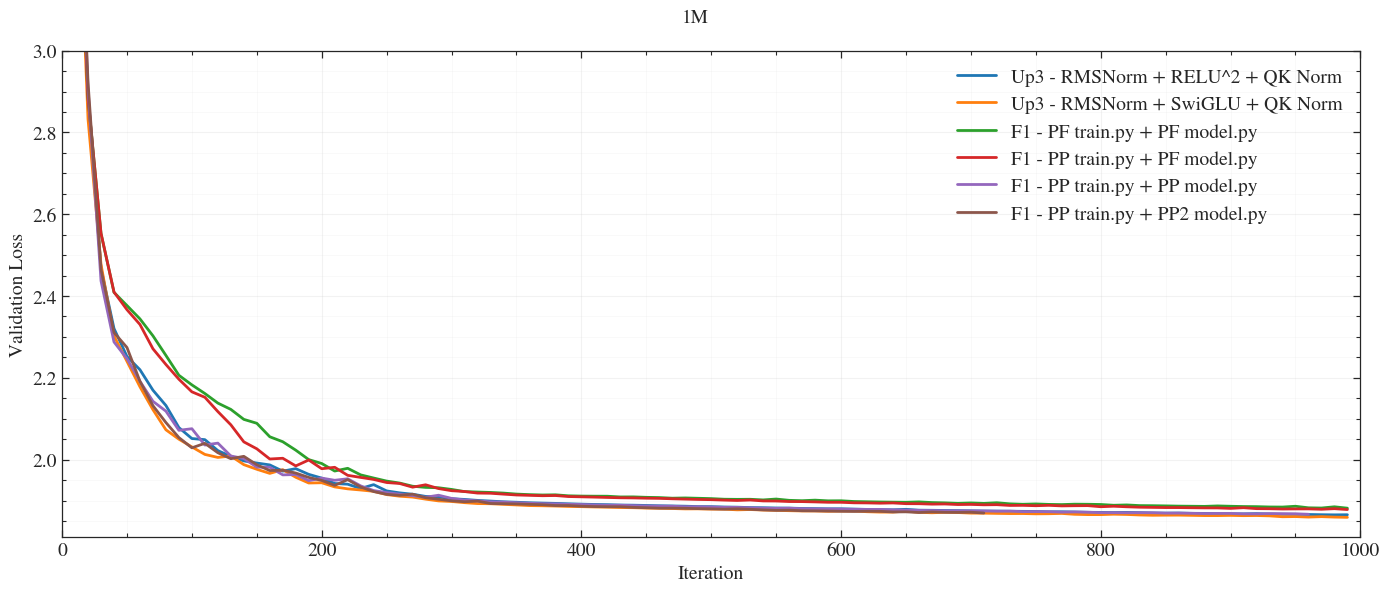

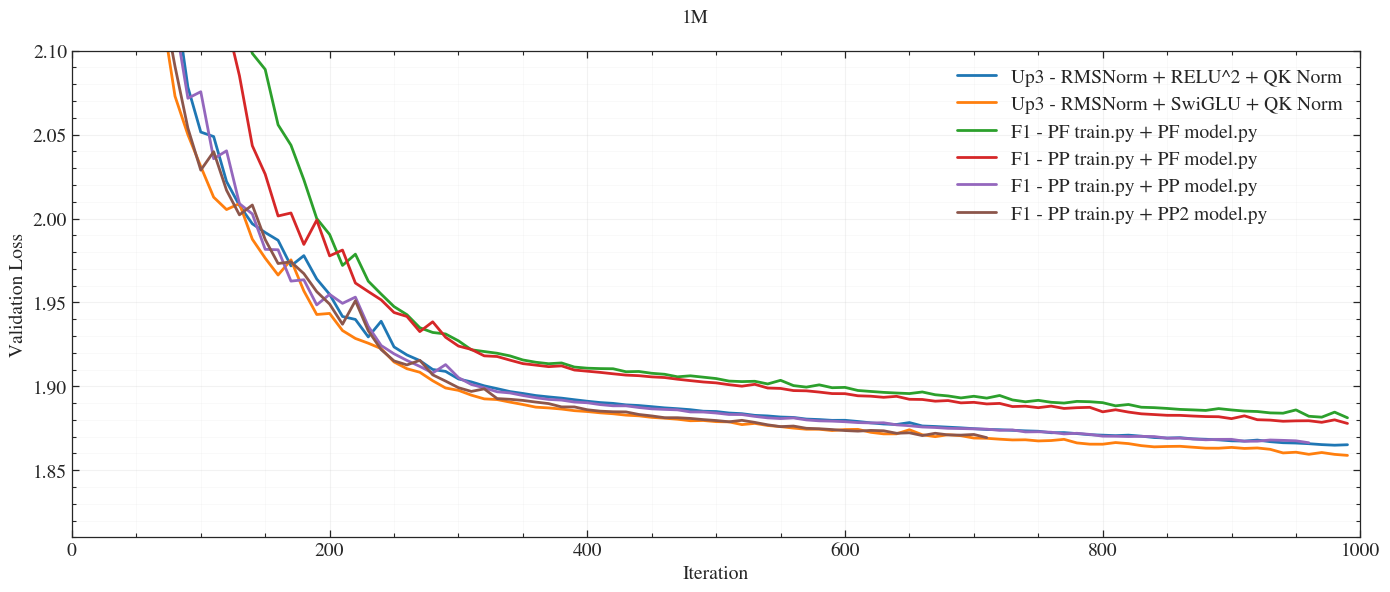

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [31]:
model_names_and_labels = {
    # Keeping these old ones for reference--Up3 QK_norm_1 and QK_norm_2 were the best from upgrade 3
    # Kept only Up3 even though I have done Up4. Up3 was better, generally.
    'model_upgrade_3_benchmarks_1_QK_norm_1': 'Up3 - RMSNorm + RELU^2 + QK Norm',
    'model_upgrade_3_benchmarks_1_QK_norm_2': 'Up3 - RMSNorm + SwiGLU + QK Norm',
    # Reference
    'model_fixes1_pf_train_and_pf_model': 'F1 - PF train.py + PF model.py',
    'model_fixes1_pp_train_pf_model': 'F1 - PP train.py + PF model.py',
    'model_fixes1_pp_train_pp_model': 'F1 - PP train.py + PP model.py',
    # model PP2 has faster path for RoPE during training
    'model_fixes1_pp_train_pp2_model': 'F1 - PP train.py + PP2 model.py',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.81, 3), x_lim=(0,1000), figsize=(14, 6), title='1M'
)
analv2.plotting_v2.plot_training_run(
    model_names, model_legend_title=model_labels,
    show_val_loss=True, use_log=False, smoothing_function=None,
    y_lim=(1.81, 2.1), x_lim=(0,1000), figsize=(14, 6), title='1M'
)

In [4]:
def parse_benchmark_log(file_path):
    """
    Parse a JSON lines log file and extract Benchmarking progress entries.
    Returns a pandas DataFrame with columns: iter, loss, train_loss, val_loss,
    time_ms, step_ms, tok_per_sec, mem_alloc_gb, mem_res_gb, mfu.
    """
    records = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
                if data.get('message') == 'Benchmarking progress':
                    # Extract only the fields we need
                    record = {
                        'iter': data.get('iter'),
                        'loss': data.get('loss'),
                        'train_loss': data.get('train_loss'),
                        'val_loss': data.get('val_loss'),
                        'time_ms': data.get('time_ms'),
                        'step_ms': data.get('step_ms'),
                        'tok_per_sec': data.get('tok_per_sec'),
                        'mem_alloc_gb': data.get('mem_alloc_gb'),
                        'mem_res_gb': data.get('mem_res_gb'),
                        'mfu': data.get('mfu'),
                    }
                    records.append(record)
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON line: {line}")
    return pd.DataFrame(records)

def plot_benchmark_metrics(df):
    """Create a multi-panel plot of all useful metrics vs iteration."""
    if df.empty:
        print("No benchmarking data found.")
        return

    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle('Benchmark Metrics vs Iteration', fontsize=14)

    # 1. Loss curves
    ax = axes[0, 0]
    ax.plot(df['iter'], df['train_loss'], 'o-', label='Train Loss', markersize=4)
    ax.plot(df['iter'], df['val_loss'], 's-', label='Val Loss', markersize=4)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_ylim(1.85, 2.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Tokens per second (throughput)
    ax = axes[0, 1]
    ax.plot(df['iter'], df['tok_per_sec'], 'o-', color='green', markersize=4)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Tokens / sec')
    ax.set_title('Throughput')
    ax.grid(True, alpha=0.3)

    # 3. Step time (ms)
    ax = axes[1, 0]
    ax.plot(df['iter'], df['step_ms'], 'o-', color='red', markersize=4)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Step time (ms)')
    ax.set_title('Iteration Latency')
    ax.grid(True, alpha=0.3)

    # 4. MFU (Model FLOPs Utilization)
    ax = axes[1, 1]
    ax.plot(df['iter'], df['mfu'], 'o-', color='purple', markersize=4)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MFU')
    ax.set_title('Model FLOPs Utilization')
    ax.grid(True, alpha=0.3)

    # 5. Memory usage (allocated and reserved)
    ax = axes[2, 0]
    ax.plot(df['iter'], df['mem_alloc_gb'], 'o-', label='Allocated', markersize=4)
    ax.plot(df['iter'], df['mem_res_gb'], 's-', label='Reserved', markersize=4)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Memory (GB)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 6. Optional: loss vs throughput correlation (scatter)
    ax = axes[2, 1]
    scatter = ax.scatter(df['tok_per_sec'], df['val_loss'], c=df['iter'], cmap='viridis', alpha=0.7)
    ax.set_xlabel('Tokens / sec')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Loss vs Throughput (colored by iteration)')
    fig.colorbar(scatter, ax=ax, label='Iteration')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def plot_overlapped_benchmarks(model_data_list):
    """
    Overlay multiple models on the same set of axes.

    Parameters:
        model_data_list: list of tuples (model_label, dataframe)
                         where dataframe contains columns as returned by parse_benchmark_log
    """
    if not model_data_list:
        print("No model data to plot.")
        return

    # Create subplots (same layout as single model)
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle('Benchmark Metrics Comparison (Multiple Models)', fontsize=14)

    # Define a color cycle
    colors = plt.cm.tab20.colors

    # 1. Loss curves (train and val in separate subplots? We'll put both in same plot but with linestyle difference)
    # To keep it readable, we plot train loss as solid lines, val loss as dashed lines.
    ax_loss = axes[0, 0]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_loss.plot(df['iter'], df['train_loss'], '-', color=color, label=f'{label} (train)', alpha=0.7)
        ax_loss.plot(df['iter'], df['val_loss'], '--', color=color, label=f'{label} (val)', alpha=0.7)
    ax_loss.set_xlabel('Iteration')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_ylim(1.85, 2.1)
    ax_loss.legend(fontsize='small', ncol=2)
    ax_loss.grid(True, alpha=0.3)

    # 2. Tokens per second
    ax_tps = axes[0, 1]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_tps.plot(df['iter'], df['tok_per_sec'], 'o-', color=color, label=label, markersize=3)
    ax_tps.set_xlabel('Iteration')
    ax_tps.set_ylabel('Tokens / sec')
    ax_tps.set_title('Throughput')
    ax_tps.legend(fontsize='small')
    ax_tps.grid(True, alpha=0.3)

    # 3. Step time
    ax_step = axes[1, 0]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_step.plot(df['iter'], df['step_ms'], 's-', color=color, label=label, markersize=3)
    ax_step.set_xlabel('Iteration')
    ax_step.set_ylabel('Step time (ms)')
    ax_step.set_ylim(30, None)
    ax_step.set_title('Iteration Latency')
    ax_step.legend(fontsize='small')
    ax_step.grid(True, alpha=0.3)

    # 4. MFU
    ax_mfu = axes[1, 1]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_mfu.plot(df['iter'], df['mfu'], '^-', color=color, label=label, markersize=3)
    ax_mfu.set_xlabel('Iteration')
    ax_mfu.set_ylabel('MFU')
    ax_mfu.set_ylim(-0.1, 0.1)
    ax_mfu.set_title('Model FLOPs Utilization')
    ax_mfu.legend(fontsize='small')
    ax_mfu.grid(True, alpha=0.3)

    # 5. Memory usage (allocated only, or show both? To keep it clean, plot allocated as solid, reserved as same color+hatch)
    ax_mem = axes[2, 0]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_mem.plot(df['iter'], df['mem_alloc_gb'], '-', color=color, label=f'{label} (alloc)', alpha=0.8)
        ax_mem.plot(df['iter'], df['mem_res_gb'], '--', color=color, label=f'{label} (res)', alpha=0.6)
    ax_mem.set_xlabel('Iteration')
    ax_mem.set_ylabel('Memory (GB)')
    ax_mem.legend(fontsize='small', ncol=2)
    ax_mem.grid(True, alpha=0.3)

    # 6. Loss vs Throughput scatter (all models in one plot, different colors)
    ax_scatter = axes[2, 1]
    for idx, (label, df) in enumerate(model_data_list):
        color = colors[idx % len(colors)]
        ax_scatter.scatter(df['tok_per_sec'], df['val_loss'], c=[color]*len(df), label=label, alpha=0.6, s=20)
    ax_scatter.set_xlabel('Tokens / sec')
    ax_scatter.set_ylabel('Validation Loss')
    ax_scatter.set_title('Loss vs Throughput')
    ax_scatter.legend(fontsize='small')
    ax_scatter.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Parsing benchmark log for model 'Up3 - RMSNorm + RELU^2 + QK Norm'
Parsing benchmark log for model 'Up3 - RMSNorm + SwiGLU + QK Norm'
Parsing benchmark log for model 'F1 - PF train.py + PF model.py'
Parsing benchmark log for model 'F1 - PP train.py + PF model.py'
Parsing benchmark log for model 'F1 - PP train.py + PP model.py'
Parsing benchmark log for model 'F1 - PP train.py + PP2 model.py'


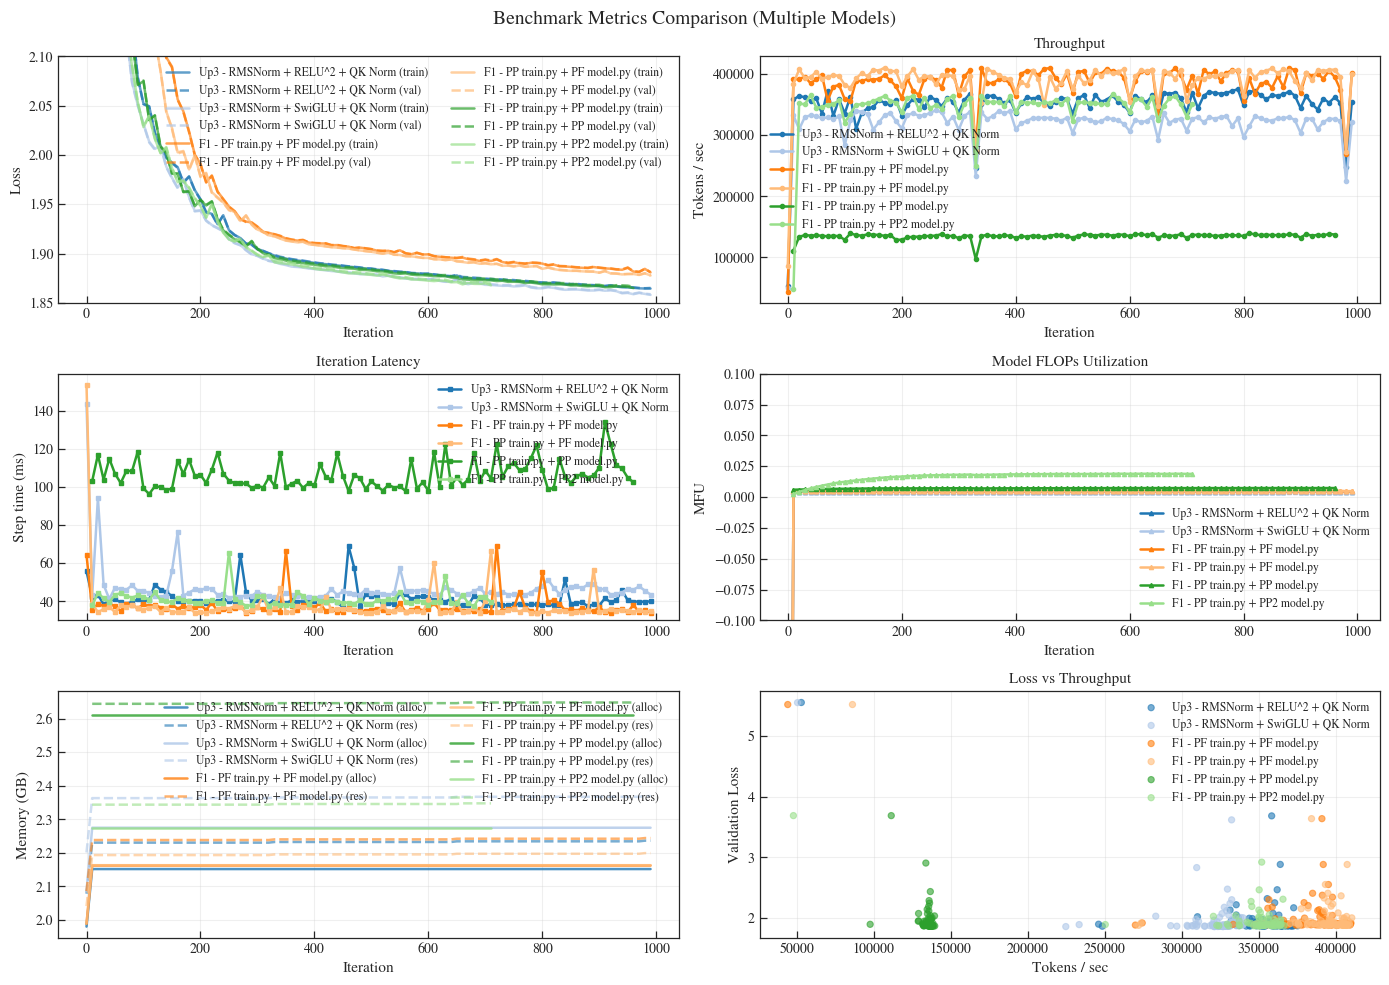

In [32]:
all_data = []   # list of (label, dataframe)
for mn, ml in zip(model_names, model_labels):
    training_log_filename = pUtil.get_training_dir(mn) / "train_log_1.jsonl"
    print(f"Parsing benchmark log for model '{ml}'")
    df = parse_benchmark_log(training_log_filename)
    all_data.append((ml, df))
        
plot_overlapped_benchmarks(all_data)

Parsing benchmark log for model 'Up3 - RMSNorm + RELU^2 + QK Norm'


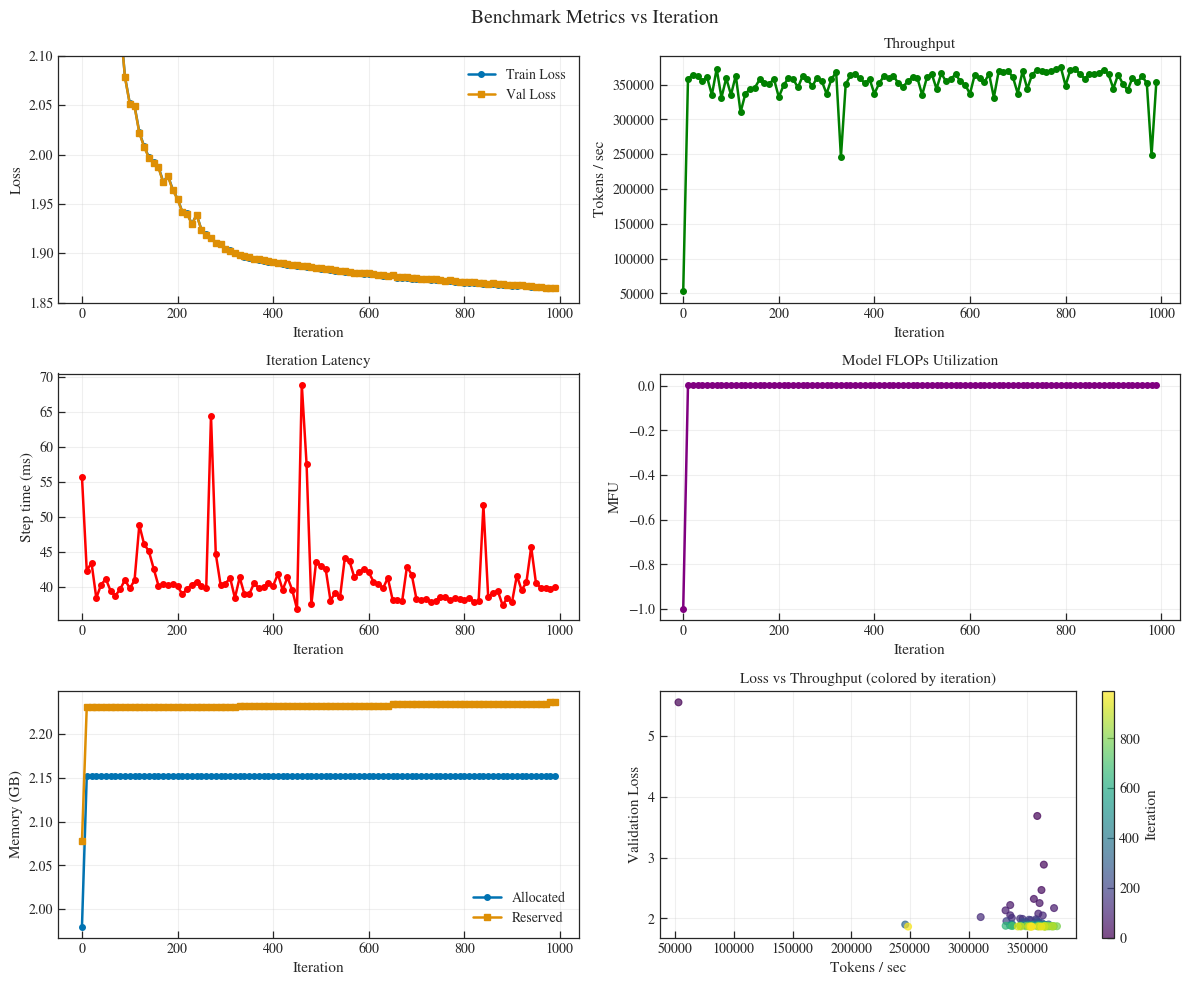

Parsing benchmark log for model 'Up3 - RMSNorm + SwiGLU + QK Norm'


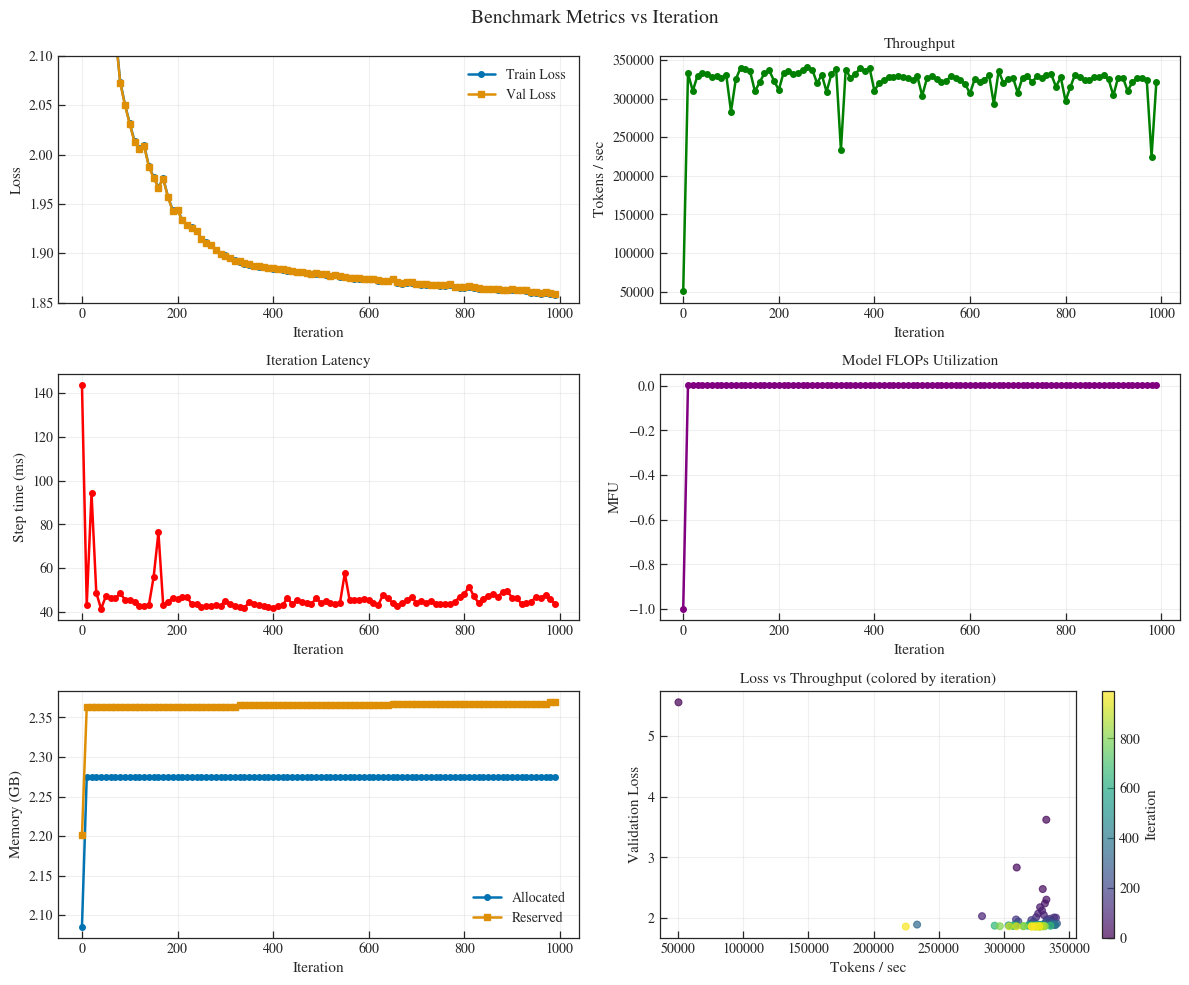

Parsing benchmark log for model 'F1 - Pre Fixes'


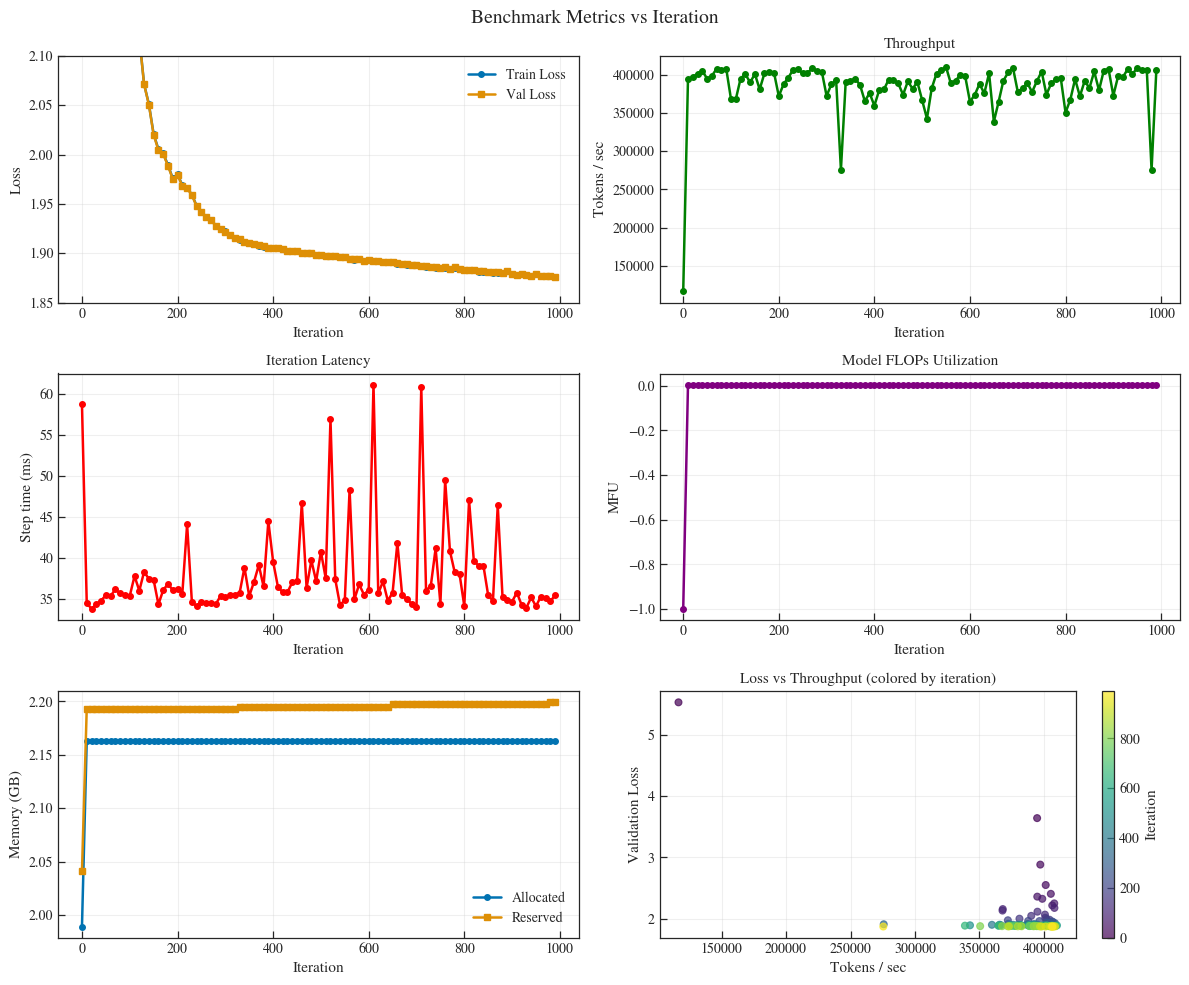

Parsing benchmark log for model 'F1 - Pre Polish pass'


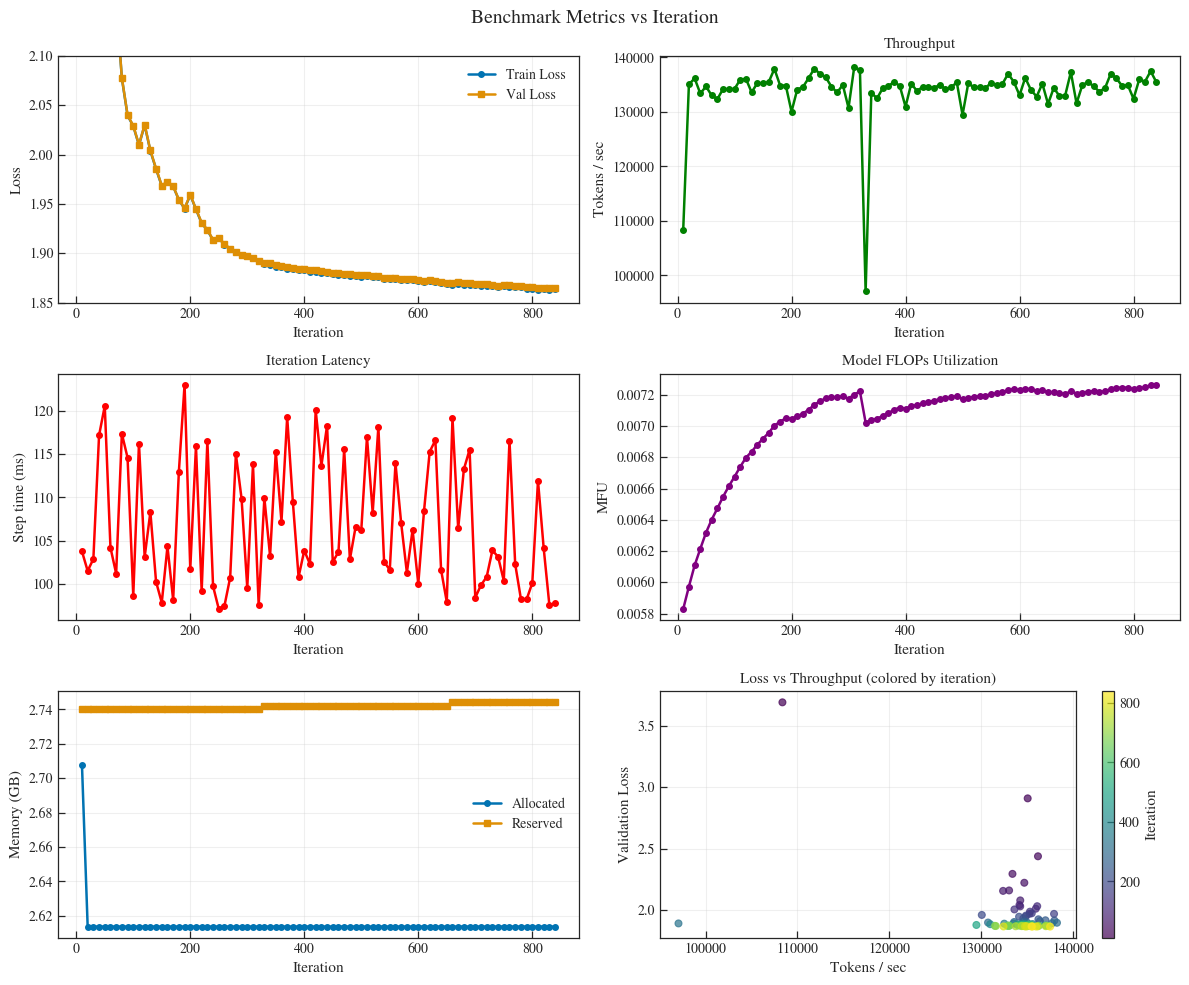

Parsing benchmark log for model 'F1 - Polish pass'


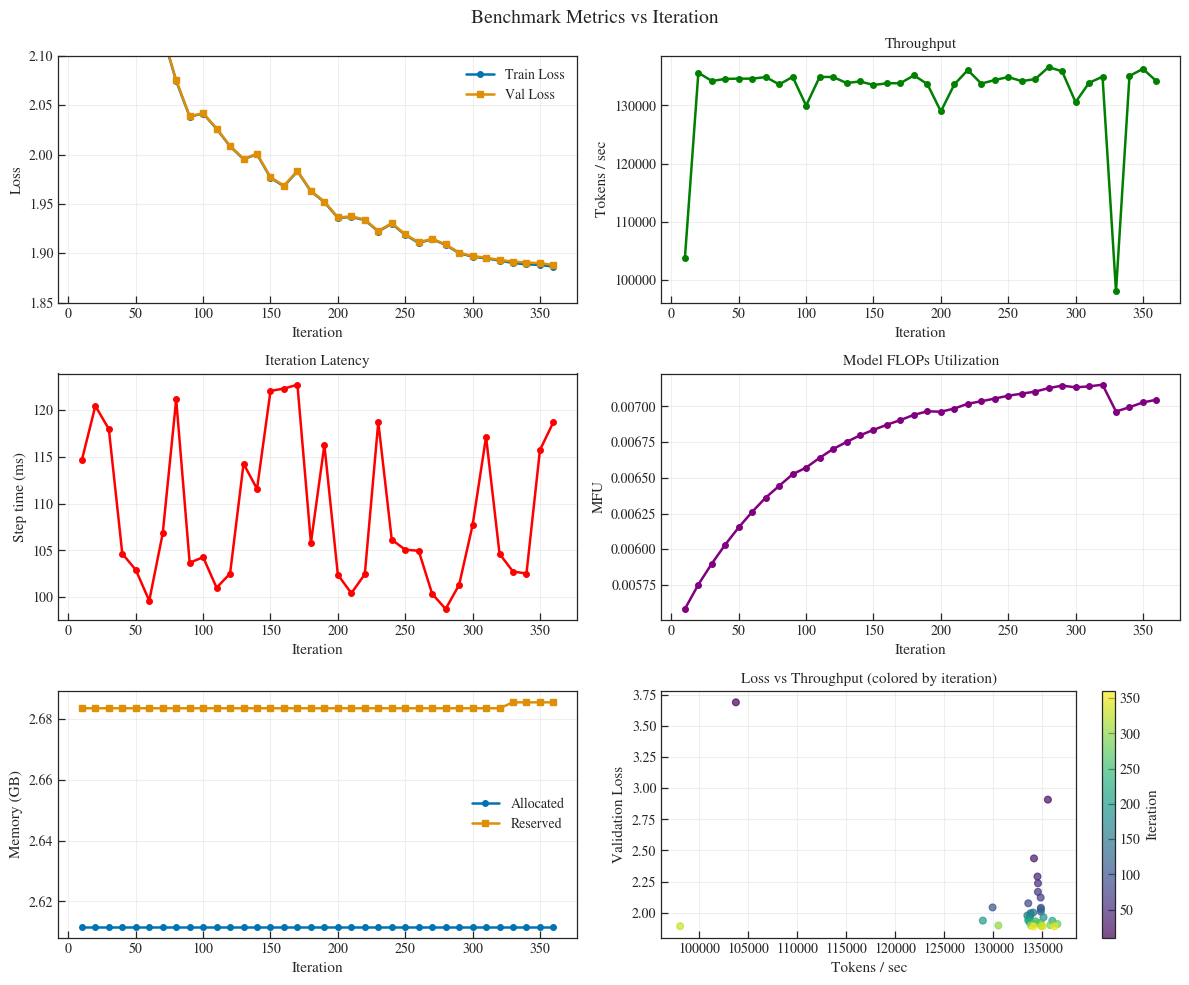

Parsing benchmark log for model 'F1 - Pre fixes train.py + fixes (no pp) model.py'


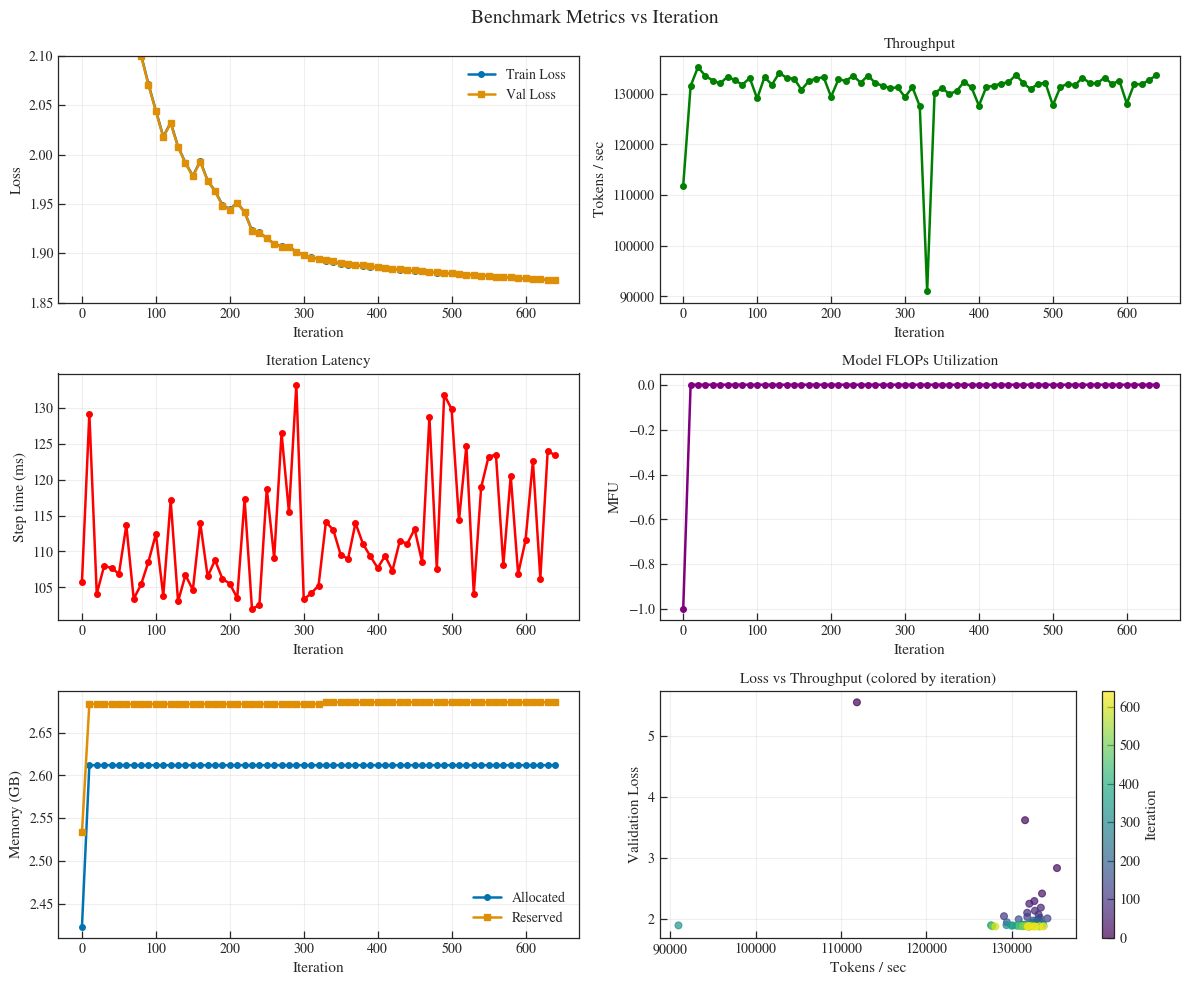

Parsing benchmark log for model 'F1 - PF train.py + PF model.py'


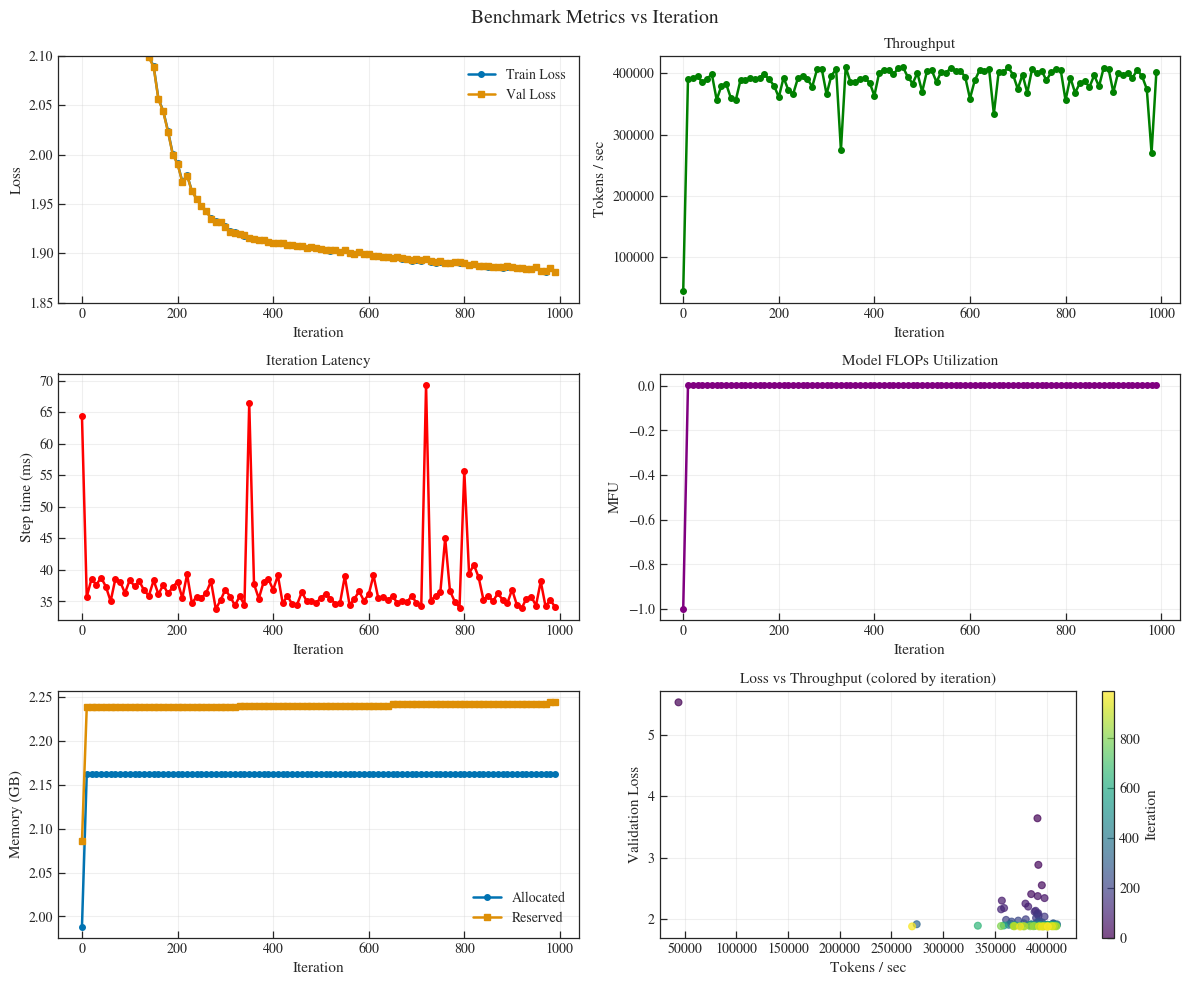

Parsing benchmark log for model 'F1 - PP train.py + PF model.py'


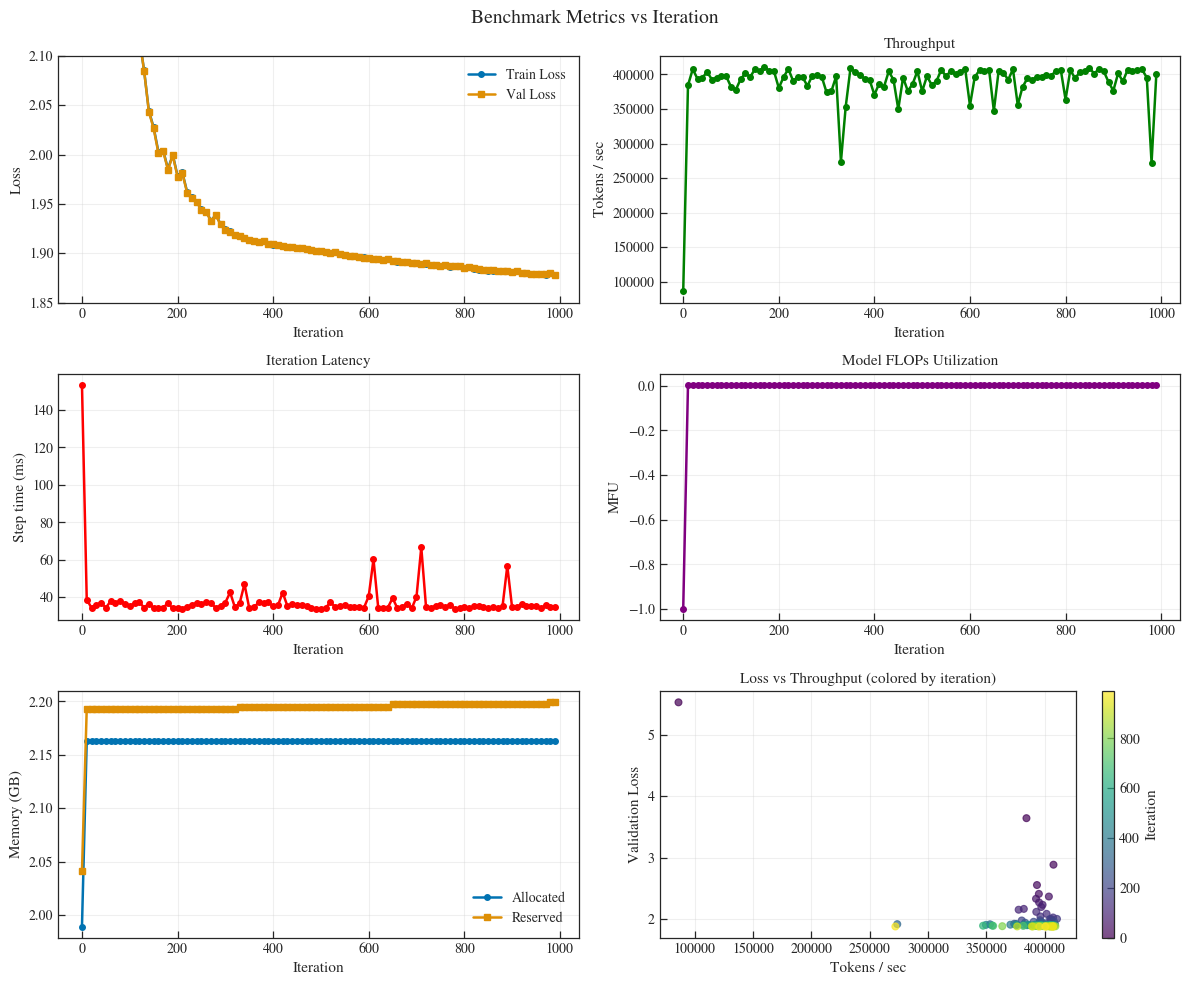

Parsing benchmark log for model 'F1 - PP train.py + PP model.py'


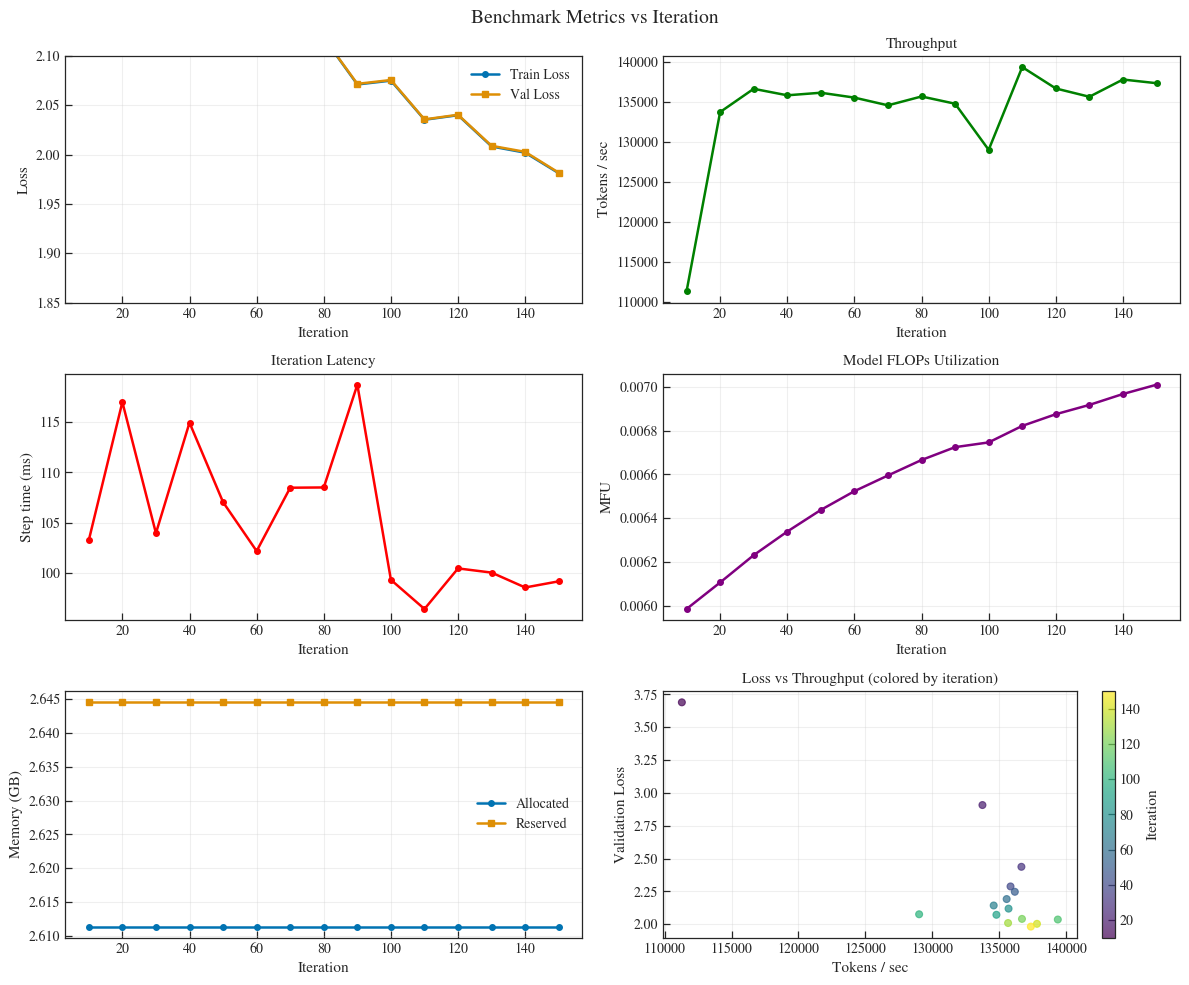

In [6]:
for mn, ml in zip(model_names, model_labels):
    training_log_filename = pUtil.get_training_dir(mn) / "train_log_1.jsonl"
    print(f"Parsing benchmark log for model '{ml}'")
    df = parse_benchmark_log(training_log_filename)
    plot_benchmark_metrics(df)